In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pprint

In [11]:
# Question 1
def box_plot(seq1,seq2):
  # Creating a matrix of matches
  box_mat = []

  for n2 in seq2:
    temp = ()
    for n1 in seq1:
      if n1 == n2:
        temp = temp + (1,)
      else:
        temp = temp + (0,)

    box_mat.append(temp)
    del temp

  cmap = ListedColormap(["black", "yellow"])

  # Creating the plot
  plt.figure(figsize=(8,6))
  plt.imshow(box_mat, cmap=cmap, origin="lower", interpolation="nearest")

  plt.xlabel("Human β-globin")
  plt.ylabel("Chicken β-globin")
  plt.title("Dot Plot: Human vs Chicken Hemoglobin β Chain")

  legend_elements = [
    Patch(facecolor='yellow', edgecolor='yellow', label='Match'),
    Patch(facecolor='black', edgecolor='black', label='Mismatch')]

  plt.legend(handles=legend_elements,
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0)

  plt.tight_layout()
  plt.show()
#===============================================================================
def aligned_segments(seq1, seq2):

    alignments = []
    start = None

    # Checking for same residues
    for n in range(min(len(seq1),len(seq2))):
        if seq1[n] == seq2[n]:
            if start is None:
                start = n
        else:
            if start is not None:
                alignments.append((start + 1, n))
                start = None

    if start is not None:
        alignments.append((start + 1, min(len(seq1), len(seq2))))

    pprint.pprint(alignments)
#===============================================================================

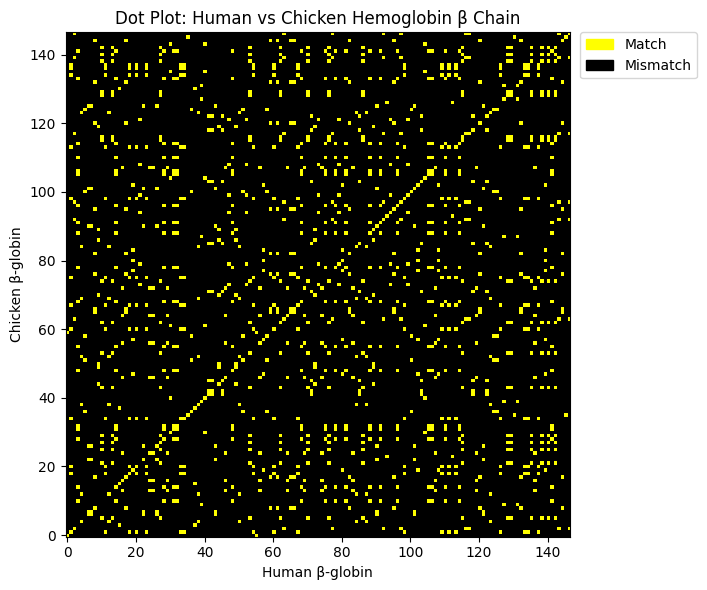

In [12]:
H_HBB = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"
C_HBB = "MVHWTAEEKQLITGLWGKVNVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAILGNPMVRAHGKKVLTSFGDAVKNLDNIKNTFSQLSELHCDKLHVDPENFRLLGDILIIVLAAHFSKDFTPECQAAWQKLVRVVAHALARKYH"

box_plot(H_HBB, C_HBB)

In [13]:
aligned_segments(H_HBB, C_HBB)

[(1, 3),
 (5, 5),
 (7, 9),
 (13, 13),
 (15, 21),
 (23, 23),
 (25, 25),
 (27, 29),
 (31, 33),
 (35, 43),
 (45, 47),
 (49, 50),
 (52, 52),
 (54, 54),
 (57, 59),
 (61, 61),
 (63, 69),
 (72, 72),
 (74, 74),
 (79, 81),
 (83, 83),
 (85, 86),
 (89, 108),
 (111, 111),
 (114, 116),
 (118, 119),
 (121, 121),
 (123, 125),
 (128, 130),
 (132, 133),
 (135, 135),
 (138, 139),
 (141, 143),
 (145, 147)]


In [14]:
# Question 2
seq1, seq2 = "AATCTATA", "AAG--ATA"

# Defining the scoring criteria
scores = {
    "match": 1,
    "mismatch": 0,
    "op": -2,
    "gp": -1}

score, n, Org = 0, 0, False

for n in range(len(seq1)):

  if seq1[n] == "-" or seq2[n] == "-":
    # Gap/Length Penalty
    if not Org:
      # Origination Penalty
      score += scores["op"]
      Org = True

    score += scores["gp"]

  # Match
  elif seq1[n] == seq2[n]:
    Org = False
    score += scores["match"]

  # Mismatch
  else:
    Org = False
    score += scores["mismatch"]

print("Score =",score)

Score = 1


In [19]:
# Question 4
def NW(seq1,seq2):

  # Defining the scoring criteria
  scores = {
    "match": 2,
    "mismatch": -1,
    "gap": -2}

  n,m = len(seq1),len(seq2)
  mat = np.zeros((n+1, m+1))

  for row in range(n+1):
    mat[row][0] = row*scores["gap"]

  for col in range(m+1):
    mat[0][col] = col*scores["gap"]

  for row in range(1,n+1):
    for col in range(1,m+1):

      # In the case of a match, calculating optimal score
      if seq1[row-1] == seq2[col-1]:
        mat[row][col] = max(mat[row-1][col]+scores["gap"], mat[row][col-1]+scores["gap"], mat[row-1][col-1]+scores["match"])

      # In the case of a mismatch, calculating optimal score
      else:
        mat[row][col] = max(mat[row-1][col]+scores["gap"], mat[row][col-1]+scores["gap"], mat[row-1][col-1]+scores["mismatch"])

  brow,bcol = n,m
  matched_1 = ""
  matched_2 = ""

  # Backtracking
  while brow > 0 and bcol > 0:

    if mat[brow-1][bcol] + scores["gap"] == mat[brow][bcol]:
      matched_1 += seq1[brow-1]
      matched_2 += "_"
      brow -= 1

    elif mat[brow][bcol-1] + scores["gap"] == mat[brow][bcol]:
      matched_1 += "_"
      matched_2 += seq2[bcol-1]
      bcol -= 1

    else:
      matched_1 += seq1[brow-1]
      matched_2 += seq2[bcol-1]
      brow -= 1
      bcol -= 1


  matched_1 = matched_1[::-1]
  matched_2 = matched_2[::-1]


  if brow!=0:
    matched_1 = seq1[:brow] + matched_1
    matched_2 = "_"*brow + matched_2

  elif bcol!=0:
    matched_1 = "_"*bcol + matched_1
    matched_2 = seq2[:bcol] + matched_2

  print(mat)
  print("Score =", mat[n][m])
  print(matched_1)
  print(matched_2)

In [20]:
s1,s2 = "ACAGTCGAACG", "ACCGTCCG"
NW(s1,s2)

[[  0.  -2.  -4.  -6.  -8. -10. -12. -14. -16.]
 [ -2.   2.   0.  -2.  -4.  -6.  -8. -10. -12.]
 [ -4.   0.   4.   2.   0.  -2.  -4.  -6.  -8.]
 [ -6.  -2.   2.   3.   1.  -1.  -3.  -5.  -7.]
 [ -8.  -4.   0.   1.   5.   3.   1.  -1.  -3.]
 [-10.  -6.  -2.  -1.   3.   7.   5.   3.   1.]
 [-12.  -8.  -4.   0.   1.   5.   9.   7.   5.]
 [-14. -10.  -6.  -2.   2.   3.   7.   8.   9.]
 [-16. -12.  -8.  -4.   0.   1.   5.   6.   7.]
 [-18. -14. -10.  -6.  -2.  -1.   3.   4.   5.]
 [-20. -16. -12.  -8.  -4.  -3.   1.   5.   3.]
 [-22. -18. -14. -10.  -6.  -5.  -1.   3.   7.]]
Score = 7.0
ACAGTCGAACG
ACCGTC___CG


In [21]:
#Question 6
def SW(seq1,seq2):

  scores = {
    "match": 2,
    "mismatch": -1,
    "gap": -2}


  n = len(seq1)
  m = len(seq2)

  mat = np.zeros((n+1, m+1))
  max_loc, greatest = (0,0),0

  for row in range(n+1):
    mat[row][0] = 0

  for col in range(m+1):
    mat[0][col] = 0

  for row in range(1,n+1):
    for col in range(1,m+1):

      # In the case of a match, calculating optimal score
      if seq1[row-1] == seq2[col-1]:
        mat[row][col] = max(mat[row-1][col]+scores["gap"], mat[row][col-1]+scores["gap"], mat[row-1][col-1]+scores["match"],0)

      # In the case of a mismatch, calculating optimal score
      else:
        mat[row][col] = max(mat[row-1][col]+scores["gap"], mat[row][col-1]+scores["gap"], mat[row-1][col-1]+scores["mismatch"],0)

      # Maximum Score to Backtrack from
      if mat[row][col] >= greatest:
        greatest = mat[row][col]
        max_loc  =(row,col)

  brow,bcol = max_loc
  matched_1 = ""
  matched_2 = ""

  # Backtracking
  while mat[brow][bcol] > 0:

    if mat[brow-1][bcol] + scores["gap"] == mat[brow][bcol]:
      matched_1 += seq1[brow-1]
      matched_2 += "_"
      brow -= 1

    elif mat[brow][bcol-1] + scores["gap"] == mat[brow][bcol]:
      matched_1 += "_"
      matched_2 += seq2[bcol-1]
      bcol -= 1

    else:
      matched_1 += seq1[brow-1]
      matched_2 += seq2[bcol-1]
      brow -= 1
      bcol -= 1


  matched_1 = matched_1[::-1]
  matched_2 = matched_2[::-1]


  print(mat)
  print("Score =", greatest)
  print(matched_1)
  print(matched_2)

In [22]:
seq1, seq2 = "ACGTATCGCGTATA", "GATGCGTATCG"
SW(seq1,seq2)

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  2.  0.  0.  0.  0.  0.  2.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  2.  0.  0.  0.  1.  2.  0.]
 [ 0.  2.  0.  0.  3.  1.  4.  2.  0.  0.  0.  4.]
 [ 0.  0.  1.  2.  1.  2.  2.  6.  4.  2.  0.  2.]
 [ 0.  0.  2.  0.  1.  0.  1.  4.  8.  6.  4.  2.]
 [ 0.  0.  0.  4.  2.  0.  0.  3.  6. 10.  8.  6.]
 [ 0.  0.  0.  2.  3.  4.  2.  1.  4.  8. 12. 10.]
 [ 0.  2.  0.  0.  4.  2.  6.  4.  2.  6. 10. 14.]
 [ 0.  0.  1.  0.  2.  6.  4.  5.  3.  4.  8. 12.]
 [ 0.  2.  0.  0.  2.  4.  8.  6.  4.  2.  6. 10.]
 [ 0.  0.  1.  2.  0.  2.  6. 10.  8.  6.  4.  8.]
 [ 0.  0.  2.  0.  1.  0.  4.  8. 12. 10.  8.  6.]
 [ 0.  0.  0.  4.  2.  0.  2.  6. 10. 14. 12. 10.]
 [ 0.  0.  2.  2.  3.  1.  0.  4.  8. 12. 13. 11.]]
Score = 14.0
ATCGCGTAT
AT_GCGTAT
